# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [19]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency


In [20]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [21]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [22]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


In [23]:
#Corregir tipo de dato 
df['date'] = pd.to_datetime(df['date'])

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  int64         
 8   gasto           40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [25]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [26]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [27]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [28]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [29]:
# Resumen estadístico de usuarios que se convirtieron
convertidos = df[df['converted'] == 1]
convertidos['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print( df['landing'].value_counts())
print("\nConteo de categorías:")
print( df['region'].value_counts())
print( df['dispositivo'].value_counts())
print("\nConteo de categorías:")
print( df['traffic_source'].value_counts())
print("\nConteo de categorías:")
print( df['user_type'].value_counts())
print("\nConteo de categorías:")
print( df['converted'].value_counts())


Conteo de categorías:
B    20018
A    19982
Name: landing, dtype: int64

Conteo de categorías:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

Conteo de categorías:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

Conteo de categorías:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

Conteo de categorías:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64

Conteo de categorías:
0    34294
1     5706
Name: converted, dtype: int64


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [33]:
# Gasto por versión
gasto_A = df[(df['converted'] == 1) & (df['landing'] == 'A')]['gasto'] #completa el código
gasto_B = df[(df['converted'] == 1) & (df['landing'] == 'B')]['gasto'] #completa el código

print("Media gasto A:", gasto_A.mean())
print("Media gasto B:", gasto_B.mean())

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

Media gasto A: 61.0865724522293
Media gasto B: 68.74536005009392


(2512, 3194)

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio de los clientes es igual en la página A y en la página B. 
- **Hipótesis alternativa (H₁):** El gasto promedio de los clientes es diferente en la página A y la página B. 

In [34]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B)


# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.36563589591332
Valor p: 1.0635288333792346e-20


### 📝 Conclusión e interpretación

**Decisión:** 

Se rechaza la hipótesis nula, existe diferencia significativa en el gasto promedio entre A y B.por que hay evidencia muy fuerte con un p-value ≤ 0.01, aceptamos un 1% de riesgo de error (≈ 99% de confianza)


**Interpretación de negocio:**  

Con base en una prueba t de dos muestras independientes, encontramos evidencia estadística de una diferencia en el gasto promedio entre las paginas A y B.
En promedio, los usuarios que convirtieron en la pagina B gastaron más que los de la pagina A.
Este resultado se basa en una muestra de usuarios que realizaron una compra y no evalúa si la diferencia observada es suficiente para justificar un cambio desde una perspectiva de negocio.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en ambas páginas. Cualquier diferencia se debe al azar del muestreo.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre ambas páginas. Hay un factor que influye en la decisión de compra.


In [35]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [36]:
# Aplicar prueba
exitos = [conversiones['A'], conversiones['B']]
observaciones = [totales['A'], totales['B']]

stat, pval = proportions_ztest(exitos, observaciones)


# Visualizar resultados
print(f"Estadístico : {stat}")
print(f"Valor p: {pval}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  

Se rechaza la hipótesis nula, existe diferencia significativa en la tasa de conversión entre A y B.por que hay evidencia muy fuerte con un p-value ≤ 0.01, aceptamos un 1% de riesgo de error (≈ 99% de confianza)


**Interpretación de negocio:**  

Con base en una prueba z para proporciones, encontramos evidencia estadística de una diferencia en la tasa de conversión entre las paginas A y B.
En particular, la página B muestra una tasa de conversión mayor que la página A.
Este resultado se basa en una muestra de usuarios y no evalúa si la magnitud de la diferencia es suficiente para justificar una decisión de negocio.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La conversión es independiente de la fuente de tráfico
- **Hipótesis alternativa (H₁):** La conversión depende de la fuente de tráfico


In [37]:
# Tabla de contingencia normalizada
tabla_n1 = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100
tabla_n1

converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


In [38]:
# Aplicar prueba

# Tabla de contingencia para prueba Chi2
tabla_1 = pd.crosstab( df["traffic_source"], df["converted"])

#Aplicacion de prueba chi-cuadrada
chi2_contingency(tabla_1) 

chi2_stat, p_value, dof, expected = chi2_contingency(tabla_1)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected) 

Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


### 📝 Conclusión e interpretación

**Decisión:**  

Rechazamos la hipótesis nula, hay evidencia de asociación entre las variables, la conversión depende de la fuente de tráfico.


**Interpretación de negocio:**  

Con base en un chi-square test de independencia, encontramos evidencia estadística de que la conversión está asociada al canal por el que llegó el usuario.
En particular, los usuarios de Email muestran una mayor tasa de conversión.
Este resultado se basa en una muestra de usuarios y no implica causalidad directa ni evalúa si esta diferencia justifica decisiones diferenciadas desde una perspectiva de negocio.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La conversión es independiente del tipo de usuario.
- **Hipótesis alternativa (H₁):** La conversión depende del tipo de usuario.


In [39]:
df['user_id'].duplicated().sum()

0

In [40]:
# Tabla de contingencia normalizada
tabla_n2 = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
tabla_n2

converted,0,1
user_type,,
Nuevo,85.641301,14.358699
Recurrente,85.909644,14.090356


In [41]:
# Aplicar prueba
# Tabla de contingencia para prueba Chi2
tabla_2 = pd.crosstab( df["user_type"], df["converted"])

#Aplicacion de prueba chi-cuadrada
chi2_contingency(tabla_2) 

chi2_stat, p_value, dof, expected = chi2_contingency(tabla_2)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected) 


Estadístico chi-cuadrado: 0.513
Valor P: 0.474
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


### 📝 Conclusión e interpretación

**Decisión:**  

Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables, la conversión depende del tipo de usuario.


**Interpretación de negocio:**  

Con base en un chi-square test de independencia, encontramos evidencia estadística de que la conversión está asociada al tipo de usuario.
En particular, los usuarios registrados en la categoría Nuevo muestran una mayor tasa de conversión que los de Recurrente.
Este resultado se basa en una muestra de usuarios y no implica causalidad directa ni evalúa si esta diferencia justifica decisiones diferenciadas desde una perspectiva de negocio.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

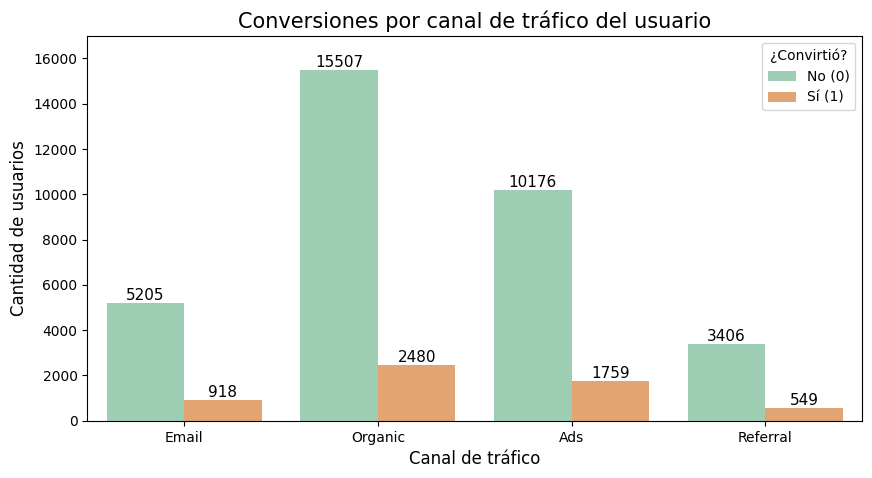

In [42]:

# Gráfico de barras agrupadas entre fuente de tráfico y conversión
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='traffic_source', hue='converted', palette = ["#95D5B2", "#F4A261"] )

# Agregar valores
for bar in ax.patches:        # Recorrer todas las barras del gráfico
    height = bar.get_height() # Obtener altura de barra (conteo de usuarios)
    ax.text(x=bar.get_x()+bar.get_width() /2, # Establecer coordenada X del texto (centro de la barra)
            y=height,                         # Establecer coordenada Y del texto
            s=height,                         # Valor a mostrar
            ha='center',                      # Alinear centro del texto en coordenada
            va='bottom',                      # Alinear parte inferior del texto en coordenada
            fontsize=11)                      # Tamaño de la fuente

# Añadir detalles
plt.title('Conversiones por canal de tráfico del usuario', fontsize=15)
plt.xlabel('Canal de tráfico', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.ylim(0,17000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()


✍️ **Comentario**:

Este gráfico muestra la cantidad de usuarios que convirtieron y no convirtieron según el tipo de fuente de tráfico por el que llegó el usuario 

Observamos que Organic y Ads concentran la mayoría del volumen, mientras que Referal y Email los siguen manteniendo una participación consistente 

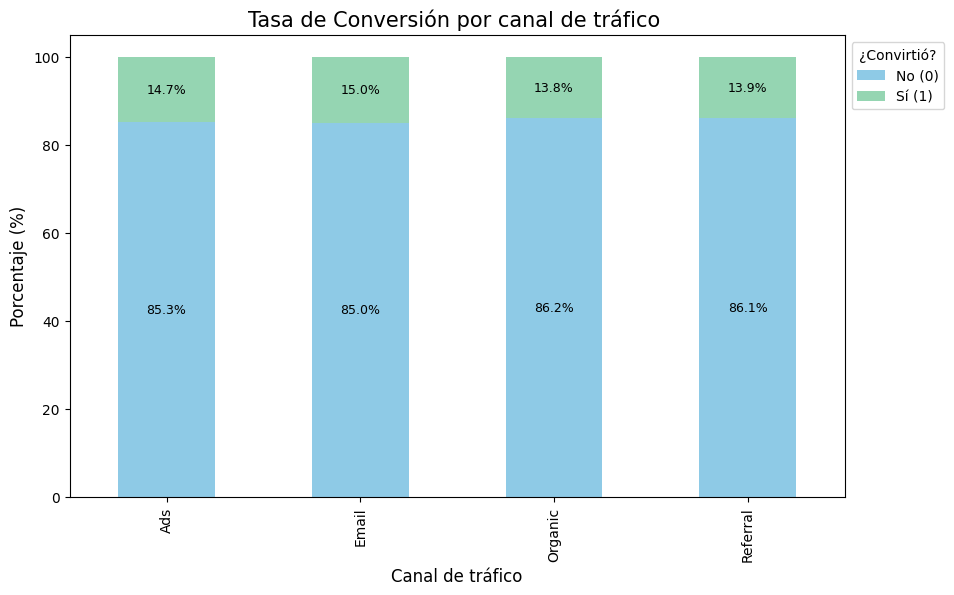

In [43]:

# Gráfica de barras apiladas
# Gráfica de barras apiladas
ax= tabla_n1.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de Conversión por canal de tráfico ', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Canal de tráfico', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()

    if height > 0:
        x = p.get_x() + width / 2
        y = p.get_y() + height / 2

        ax.text(x, y, f'{height:.1f}%',
                ha='center', va='center', fontsize=9)
plt.show() 


✍️ **Comentario**:

Este gráfico muestra la taza de conversión por fuente de tráfico, independientemente del volumen total.

Vemos que Email es la categoría con mayor porcentaje de conversión.

### Relación entre el tipo de usuario y la conversión

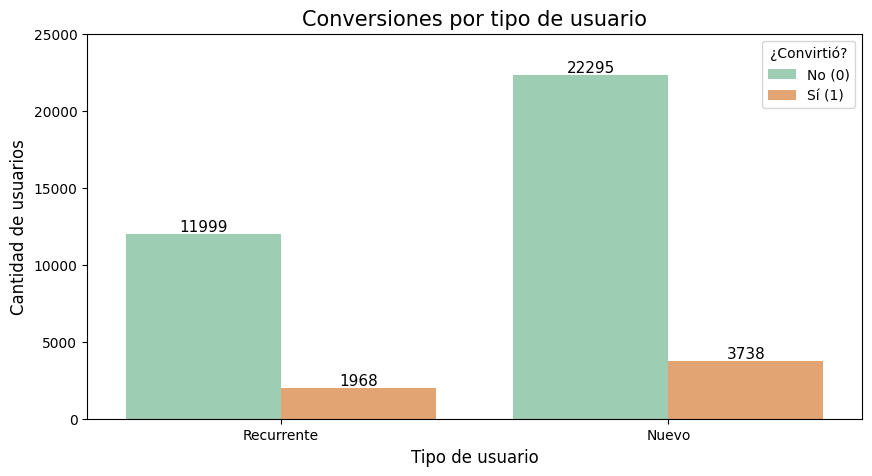

In [44]:

# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='user_type', hue='converted', palette = ["#95D5B2", "#F4A261"] )

# Agregar valores
for bar in ax.patches:        # Recorrer todas las barras del gráfico
    height = bar.get_height() # Obtener altura de barra (conteo de usuarios)
    ax.text(x=bar.get_x()+bar.get_width() /2, # Establecer coordenada X del texto (centro de la barra)
            y=height,                         # Establecer coordenada Y del texto
            s=height,                         # Valor a mostrar
            ha='center',                      # Alinear centro del texto en coordenada
            va='bottom',                      # Alinear parte inferior del texto en coordenada
            fontsize=11)                      # Tamaño de la fuente

# Añadir detalles
plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.ylim(0,25000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()


✍️ **Comentario**: 

Este gráfico muestra la cantidad de usuarios que convirtieron y no convirtieron segun el tipo de usuario 

Observamos que Nuevo es la categoría que concentra la mayoría del volumen seguida de Recurrente con más de la mitad de clientes Nuevos

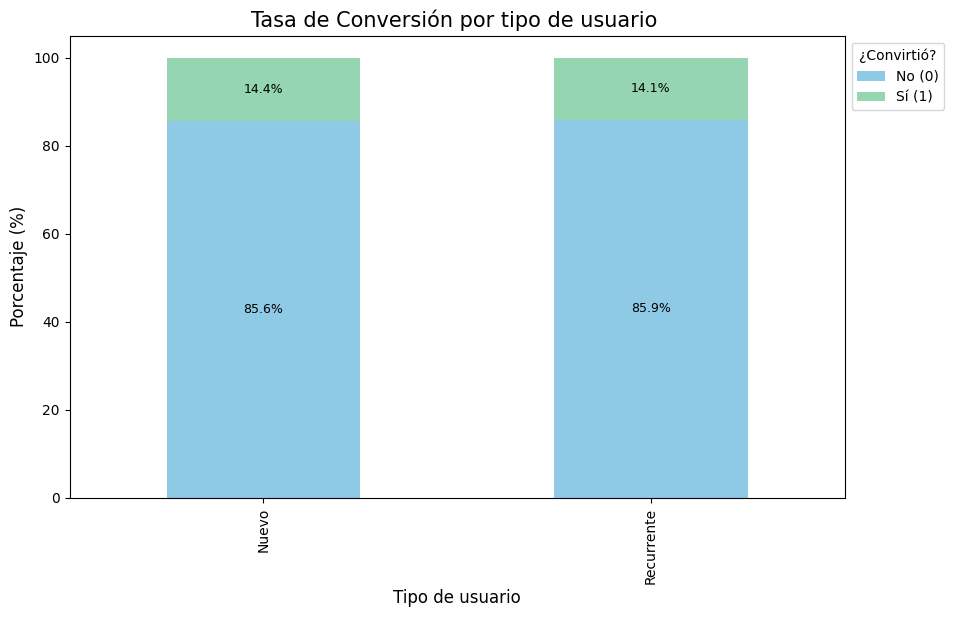

In [45]:
# Gráfica de barras apiladas
ax= tabla_n2.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de Conversión por tipo de usuario ', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()

    if height > 0:
        x = p.get_x() + width / 2
        y = p.get_y() + height / 2

        ax.text(x, y, f'{height:.1f}%',
                ha='center', va='center', fontsize=9)
plt.show() 

✍️ **Comentario**: 

Este gráfico muestra la taza de conversion por tipo de usuario independientemente del volumen total.

Vemos que la categoría Nuevo es la categoría con mayor porcentaje de conversión.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Bien hecho aquí con las comparaciones entre usuarios que convierten y no convierten y sus tipos. Como mencionas, se aprecia que las tasas de conversión son similares entre usuarios nuevos y recurrentes.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**


- Página A: \$61.09 promedio por usuario convertido (2,512 usuarios)
- Página B: \$68.75 promedio por usuario convertido (3,194 usuarios)
- Diferencia: \$7.66 más en página B

- **Interpretación:**
-  La Página B superó a la Página A por un margen de $7.66 por usuario, los promedios sugieren que la Página B es más efectiva para incentivar compras de mayor valor.


**Tasa de conversión:** 
- Página A: 2,512 conversiones de 19,982 usuarios = 12.57%
- Página B: 3,194 conversiones de 20,018 usuarios = 15.95%

- **Interpretación:**
- La diferencia en las tasas de conversión sugiere que la pagina B convierte 3.38 puntos porcentuales más que la página
A, esto respresetna un 27% de mejora relativa (15.95% vs 12.57%), por cada 1000 visitantes página B genera aproximadamente 40 clientes más
---

#### 📊 **Segmentación por canal de tráfico**
- Observamos que Organic y Ads concentran la mayoría del volumen, mientras que Referal y Email los siguen manteniendo una participación consistente
- **Interpretación:**
 Los canales pagados y de comunicación directa (Email, Ads) superan en efectividad a los canales orgánicos, indicando que la inversión en marketing dirigido genera mejores resultados de conversión que el tráfico espontáneo.
 ---

#### 📊 **Segmentación por tipo de usuario**
- Los usuarios nuevos representan la mayoría del tráfico (65%) y muestran una tasa de conversión ligeramente superior (14.36% vs 14.09%)
- La diferencia en tasas de conversión entre usuarios nuevos y recurrentes no es estadísticamente significativa (p=0.474)
- Ambos segmentos mantienen tasas de conversión similares, sugiriendo que la efectividad de la página no depende significativamente del historial previo del usuario

- **Interpretación:**
La página funciona de manera consistente para ambos tipos de usuarios, lo que indica que el diseño y contenido son efectivos tanto para atraer nuevos clientes como para mantener el interés de usuarios que ya han interactuado previamente con la marca. Aunque la pequeña diferencia en la taza de conversion pueda significar un mayor volumen de clientes convertidos por numero de clientes contactados 
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Implementar la pagina B 
- Invertir más presupuesto en los canales Email y Ads para aumentar el volumen de conversiones 
- Atender equitativamente campañas de marketing para ambos tipos de clientes, nuevos y recurrentes 
- Optimizar la página ganadora: Implementar mejoras de UX y pruebas A/B adicionales para seguir elevando la conversión